# Topical Lectures, Controls 
## Drone control, part 6: trajectory shaping

Andreas Freise, 27.05.2026

Notebook 5 inverted the drone dynamics so the controller could ask for
an acceleration and get the right tilt and thrust. That fixed the
coupling between altitude and heading, but the drone still overshoots
every waypoint because the setpoint jumps instantly from one corner of
the track to the next. The PIDs are asked for the largest acceleration
they can deliver and the safety wedge clips for most of the race.

In this notebook we replace the step setpoint with a smooth trajectory
between waypoints. The PIDs see a steadily-moving target and add a
small correction on top of the trajectory feedforward.


In [1]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt
import time
import module
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

# Don't forget to set the name string to your own name
MyName = "Andreas"


## Why a trajectory

A step from one waypoint to the next has infinite acceleration at the transition. The PIDs in notebook 5 cannot follow that, so they overshoot at every corner. A smooth trajectory replaces the step with a function $y_0(t), z_0(t)$ that the drone *can* follow.

We will take this one step further. Instead of bringing the drone to rest at every waypoint (which throws away momentum on a track without sharp dead-ends), we plan a trajectory that passes *through* every intermediate waypoint at a non-zero velocity, only coming to rest at the very last one. The trajectory naturally bends outward before each corner so that the drone is already aligned with the next leg when it crosses the waypoint, the way a race driver carries momentum through an apex.

The control stack stays the same as notebook 5: outer PIDs, the algebraic `accel_to_phi_F` inversion, an inner phi PD. The trajectory adds three new ingredients on top:

1. The position setpoint is now time-varying.
2. The PIDs track a moving setpoint, which means the velocity error is $\dot{y} - \dot{y}_0(t)$ rather than $\dot{y}$ alone. The `PIDController` class takes a `setpoint_dot` argument for exactly this.
3. The trajectory acceleration $\ddot{y}_0(t), \ddot{z}_0(t)$ goes directly into the inversion as feedforward. The PID then only has to suppress the small residual error between drone and trajectory, not generate the commanded motion.

In [2]:
# Measured parameters for the Crazyflie-scale drone (SI units throughout).
# These would normally come from the student2 system-identification notebook.
V_left_offset = -0.0027   # throttle units; cancels left/right asymmetry
V_hover = 0.5297          # per-motor throttle at hover (= M*g/2 / amp)
V_max = 1.0               # throttle range upper bound
V_min = 0                 # motors are single-direction

# Common-mode / differential decomposition for motor mixing.
# Total motor command must stay in [V_min, V_max]; the differential is
# bounded by the headroom that the common-mode thrust leaves on each side.

def set_v(drone, _V_left, _V_right):
    V_left = V_hover + _V_left + V_left_offset
    V_right = V_hover + _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def set_v_nohover(drone, _V_left, _V_right):
    V_left = _V_left + V_left_offset
    V_right = _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def zphi2V(fb_z, fb_phi):
    V_left = fb_z + fb_phi
    V_right = fb_z - fb_phi
    return V_left, V_right


## Quintic segments with non-zero boundary velocity

A rest-to-rest minimum-jerk segment between $(y_0, 0, 0)$ and $(y_T, 0, 0)$ uses the polynomial $s(\tau) = 10\tau^3 - 15\tau^4 + 6\tau^5$. We generalise to non-zero boundary velocities $\dot{y}_0, \dot{y}_T$ (the boundary accelerations stay zero, so consecutive segments still join smoothly).

A quintic $y(\tau) = a_0 + a_1 \tau + a_2 \tau^2 + a_3 \tau^3 + a_4 \tau^4 + a_5 \tau^5$ has six coefficients and six boundary conditions:

* $y(0) = y_0$, $y(1) = y_T$
* $\dot{y}(0)/T = \dot{y}_0$, $\dot{y}(1)/T = \dot{y}_T$
* $\ddot{y}(0)/T^2 = 0$, $\ddot{y}(1)/T^2 = 0$

Solving gives $a_0 = y_0$, $a_1 = T\dot{y}_0$, $a_2 = 0$, and for the cubic-and-higher part with $D = y_T - y_0 - T\dot{y}_0$ and $V = T(\dot{y}_T - \dot{y}_0)$:

$$a_3 = 10D - 4V, \quad a_4 = -15D + 7V, \quad a_5 = 6D - 3V.$$

For $\dot{y}_0 = \dot{y}_T = 0$ this collapses to the classical $a_3 = 10D,\ a_4 = -15D,\ a_5 = 6D$.

### Choosing the velocity at each waypoint

At each interior waypoint $W_k$ we set the velocity along the bisector of the incoming direction $(W_k - W_{k-1})$ and the outgoing direction $(W_{k+1} - W_k)$, with magnitude $v_{\mathrm{cruise}}$. The bisector is the direction in which the drone is naturally moving as it passes through the waypoint along a smooth curve, and it keeps the trajectory's outward bend (the *spiral* around each corner) as small as possible. At the start and the final waypoint the velocity is zero.

### Choosing the segment duration $T$

We pick $T$ for each segment so the peak commanded acceleration stays within an `a_plan` budget that is smaller than the drone's physical limit. The headroom matters because it is what lets the PID correct tracking lag without immediately saturating the safety wedge. With no headroom the PID has no authority to catch up when the drone falls behind, and the drone misses every waypoint.

In [3]:
class FlyThroughTrajectory:
    """Sequence of quintic minimum-jerk segments that pass *through* each
    waypoint at a non-zero velocity (except the first and last, which
    start and end at rest). The trajectory is built once at construction
    time. Two lookup methods are provided:

    * ``setpoint(t)`` -- by absolute time, mostly useful for visualisation.
    * ``closest_t(y, z, t_hint)`` -- find the trajectory time whose
      position is closest to ``(y, z)``. Used at run-time so the drone
      tracks the path's *shape*, not its *timing*; otherwise the drone's
      tracking lag would let the future setpoint pull it inside every
      corner."""

    def __init__(self, waypoints, v_cruise, ay_plan, az_plan, t_start=0.0):
        # Velocity at each waypoint: bisector of incoming / outgoing
        # directions, magnitude v_cruise. Endpoints at rest.
        N = len(waypoints)
        vels = np.zeros((N, 2))
        for k in range(1, N - 1):
            inc = waypoints[k] - waypoints[k - 1]
            inc = inc / np.linalg.norm(inc)
            out = waypoints[k + 1] - waypoints[k]
            out = out / np.linalg.norm(out)
            bisector = inc + out
            nb = np.linalg.norm(bisector)
            if nb > 1e-6:
                vels[k] = v_cruise * bisector / nb
        # Build per-segment quintics back-to-back in absolute time.
        self.segs = []
        t = t_start
        for k in range(N - 1):
            T = self._pick_T(waypoints[k],     vels[k],
                             waypoints[k + 1], vels[k + 1],
                             ay_plan, az_plan)
            cy = self._coef(waypoints[k][0],     vels[k][0],
                            waypoints[k + 1][0], vels[k + 1][0], T)
            cz = self._coef(waypoints[k][1],     vels[k][1],
                            waypoints[k + 1][1], vels[k + 1][1], T)
            self.segs.append({'t0': t, 'T': T, 'cy': cy, 'cz': cz})
            t += T
        self.t_end = t

    @staticmethod
    def _coef(p0, v0, pT, vT, T):
        a0 = p0
        a1 = T * v0
        a2 = 0.0
        D = pT - p0 - T * v0
        V = T * (vT - v0)
        return np.array([a0, a1, a2,
                         10 * D - 4 * V,
                         -15 * D + 7 * V,
                         6 * D - 3 * V])

    @staticmethod
    def _eval(coefs, T, t_local):
        if t_local >= T:
            return float(np.sum(coefs)), 0.0, 0.0
        tau = max(0.0, t_local / T)
        p   = np.array([1, tau, tau**2, tau**3, tau**4, tau**5])
        dp  = np.array([0, 1, 2*tau, 3*tau**2, 4*tau**3, 5*tau**4]) / T
        ddp = np.array([0, 0, 2, 6*tau, 12*tau**2, 20*tau**3]) / T**2
        return float(coefs @ p), float(coefs @ dp), float(coefs @ ddp)

    @classmethod
    def _pick_T(cls, p0, v0, pT, vT, ay_plan, az_plan):
        T = 1.0
        for _ in range(8):
            cy = cls._coef(p0[0], v0[0], pT[0], vT[0], T)
            cz = cls._coef(p0[1], v0[1], pT[1], vT[1], T)
            peak_ay = peak_az = 0.0
            for tau in np.linspace(0, 1, 60):
                _, _, ddy = cls._eval(cy, T, tau * T)
                _, _, ddz = cls._eval(cz, T, tau * T)
                peak_ay = max(peak_ay, abs(ddy))
                peak_az = max(peak_az, abs(ddz))
            if peak_ay <= ay_plan * 1.001 and peak_az <= az_plan * 1.001:
                return T
            T *= np.sqrt(max(peak_ay / ay_plan, peak_az / az_plan))
        return T

    def setpoint(self, t_now):
        """Return (y, z, dy, dz, ddy, ddz) at trajectory time t_now."""
        for s in self.segs:
            if t_now < s['t0'] + s['T']:
                tl = t_now - s['t0']
                y,  dy,  ddy = self._eval(s['cy'], s['T'], tl)
                z,  dz,  ddz = self._eval(s['cz'], s['T'], tl)
                return y, z, dy, dz, ddy, ddz
        # Past the end: freeze at the final waypoint.
        s = self.segs[-1]
        y, _, _ = self._eval(s['cy'], s['T'], s['T'])
        z, _, _ = self._eval(s['cz'], s['T'], s['T'])
        return y, z, 0.0, 0.0, 0.0, 0.0

    def closest_t(self, y, z, t_hint, window=0.5):
        """Find the trajectory time whose position is closest to (y, z).
        Searched in ``[t_hint - window, t_hint + window]`` (clamped to the
        trajectory bounds). The window is small so we follow the drone's
        forward progress and do not jump to spatially-similar points
        that lie elsewhere on the path."""
        t_lo = max(0.0, t_hint - window)
        t_hi = min(self.t_end, t_hint + window)
        best_t = t_hint
        best_d2 = float('inf')
        # Coarse scan.
        for t_try in np.linspace(t_lo, t_hi, 41):
            ty, tz, _, _, _, _ = self.setpoint(t_try)
            d2 = (ty - y)**2 + (tz - z)**2
            if d2 < best_d2:
                best_d2 = d2; best_t = t_try
        # Local refinement around the best coarse candidate.
        for t_try in np.linspace(best_t - 0.05, best_t + 0.05, 21):
            t_try = max(0.0, min(self.t_end, t_try))
            ty, tz, _, _, _, _ = self.setpoint(t_try)
            d2 = (ty - y)**2 + (tz - z)**2
            if d2 < best_d2:
                best_d2 = d2; best_t = t_try
        return best_t

## Controllers and the trajectory

The controller stack is the same one we used in notebook 5: outer PIDs that produce a correction on the desired acceleration, the algebraic inversion `accel_to_phi_F`, and an inner phi PD. The change is that the PID `setpoint` is the trajectory position $y_0(t)$, the `setpoint_dot` argument is the trajectory velocity $\dot{y}_0(t)$, and the trajectory acceleration $\ddot{y}_0(t)$ feeds directly into the inversion as feedforward.

We can drop the inner velocity cascade from notebook 5 because the trajectory's velocity feedforward does that job: when the drone is on the trajectory the velocity error is zero by construction. The PID is only there to suppress the small residual error.

### Looking up the setpoint by position, not by time

A naive implementation would set the trajectory lookup time to the simulation time and let the PID chase whatever point on the trajectory corresponds to "now". This works, but it has a systematic problem: the drone has a small tracking lag, so by the time it reaches each point in space the trajectory has already moved past, the setpoint is heading back along the path, and the PID pulls the drone *inwards* through every corner. The actual path ends up consistently inside the planned spirals. Adding wind, or raising the gain, makes this worse rather than better.

We fix it by switching the lookup from "by time" to "by position". At every step we ask the trajectory: which time corresponds to the point closest to the drone right now? That projection point is what we use to compute the velocity and acceleration feedforward.

### Lookahead along the tangent, not along the trajectory

If the position setpoint is exactly the projection point, the PID error is zero and the drone has no carrot to chase. We need a small look-ahead. But "look ahead in trajectory time" reintroduces the corner-cutting problem: a few tens of milliseconds past a tight peak crosses the peak and lands on the inside of the trajectory. The drone is then pulled inwards again, especially with a fast trajectory (large `a_plan`).

Instead, we step along the *tangent line* at the projection point:

$$\mathbf{r}_{\mathrm{setpoint}} = \mathbf{r}(t_{\mathrm{proj}}) + \ell\, \dot{\mathbf{r}}(t_{\mathrm{proj}})$$

The tangent does not bend, so the setpoint stays outside the inside of any corner. The velocity and acceleration feedforwards stay at the projection point. The result: higher PID gain or higher `a_plan` both *tighten* the tracking, instead of curling the path inwards.

In [4]:
# Outer position PIDs (with velocity feedforward via setpoint_dot).
# With the tangent-extrapolation lookahead below, higher gain tightens
# the path instead of cutting corners, so we use stiff gains.
ay_ctrl  = module.PIDController(Kp=30.0, Ki=0, Kd=7.0)
az_ctrl  = module.PIDController(Kp=30.0, Ki=0, Kd=7.0)
phi_ctrl = module.PIDController(Kp=0.3,  Ki=0, Kd=0.06)

# Trajectory planning parameters. a_plan can sit close to the drone's
# actual acceleration capability (~8 m/s^2 at the wedge limit) because
# the tangent lookahead does not cross peaks, so increasing a_plan no
# longer drags the drone inside the corners.
v_cruise    = 1.5                  # m/s, speed through intermediate waypoints
a_plan      = 6.0                  # m/s^2, trajectory acceleration budget
phi_max_des = np.deg2rad(40)       # safety wedge
az_min      = -0.5 * 9.8

# Lookahead along the tangent line at the projection point, in seconds.
# r_setpoint = r(t_proj) + lookahead * v(t_proj). Tangent steps do not
# bend, so the setpoint never crosses into the inside of a corner the
# way "look ahead in trajectory time" does -- which means a_plan can be
# pushed close to the drone's physical limit without the drift coming
# back.
lookahead   = 0.05                 # seconds

## Race the track


In [5]:
drone = module.Drone(name=MyName, wind=True)

targets = np.array([
    [ 1.0,  1.5, 0.1],
    [ 1.0, -1.5, 0.1],
    [-1.0, -1.5, 0.1],
    [-1.0,  1.5, 0.1],
    [   0,    0, 0.1]
])
drone.set_targets(targets)

# Plan the full trajectory from the start (origin) through every target.
# Including [0, 0] as the implicit first waypoint lets the planner pick
# the right initial bend out of rest.
waypoints = np.vstack([[0.0, 0.0], targets[:, :2]])
traj = FlyThroughTrajectory(waypoints, v_cruise, a_plan, a_plan)
print(f"Planned trajectory length: {traj.t_end:.2f} s")

N = 200 * 60
Nidx = N - 1
results = np.zeros([N, 14])
traj_log = np.zeros([N, 2])
V_left = V_right = 0

ay_ctrl.reset(); az_ctrl.reset(); phi_ctrl.reset()

# t_traj_hint is the trajectory time corresponding to the drone's current
# position on the path. Monotonically non-decreasing so we never jump
# back to an earlier loop of the trajectory.
t_traj_hint = 0.0

for i in range(N):
    state = drone.update()
    results[i, 0:12] = module.state_to_array(state)
    results[i, 12:14] = [V_left, V_right]

    idx = drone.target_idx
    if idx == drone.num_targets:
        Nidx = i
        break

    # Project the drone's current position onto the trajectory. The
    # search window stays narrow so we follow the drone's progress.
    t_proj = traj.closest_t(state.y, state.z, t_traj_hint, window=0.5)
    t_traj_hint = max(t_traj_hint, t_proj)

    # Sample the trajectory at the projection point: position and
    # velocity that the drone "should" have at this point on the path.
    y_p, z_p, dy_p, dz_p, _, _ = traj.setpoint(t_proj)
    # The quintic has zero acceleration at every segment endpoint,
    # including the very start and very end of the whole trajectory.
    # If we used that current acceleration as the feedforward, the
    # drone would sit at the start with no command and only drift away
    # after the wind perturbed it. Sampling one lookahead step ahead
    # of the projection gives a non-zero feedforward at the start and
    # does not change behaviour at the mid-segment peaks (where the
    # acceleration profile is smooth and the small advance is harmless).
    t_la = min(t_proj + lookahead, traj.t_end)
    _, _, _, _, ddy0_t, ddz0_t = traj.setpoint(t_la)

    # Position setpoint = projection point + tangent step. The tangent
    # is a straight line, so this never lands on the inside of a corner.
    y0_t = y_p + lookahead * dy_p
    z0_t = z_p + lookahead * dz_p
    # Velocity feedforward stays at the projection point so it matches
    # the tangent direction.
    dy0_t, dz0_t = dy_p, dz_p
    traj_log[i] = [y0_t, z0_t]

    # PID correction with velocity feedforward through setpoint_dot.
    a_y_corr = -ay_ctrl(state.y, state.dy, y0_t, setpoint_dot=dy0_t)
    a_z_corr = -az_ctrl(state.z, state.dz, z0_t, setpoint_dot=dz0_t)

    # Acceleration feedforward + PID correction.
    a_y_des = ddy0_t + a_y_corr
    a_z_des = ddz0_t + a_z_corr

    # Safety wedge so phi_des stays within [-phi_max_des, +phi_max_des].
    a_z_des = max(a_z_des, az_min)
    a_y_bound = (a_z_des + drone.g) * np.tan(phi_max_des)
    a_y_des = float(np.clip(a_y_des, -a_y_bound, a_y_bound))

    # Inversion + inner phi PD + motor mix (same as notebook 5).
    phi_des, F_des = module.accel_to_phi_F(a_y_des, a_z_des,
                                           M=drone.M, g=drone.g)
    phi_fb = phi_ctrl(state.phi, state.dphi, phi_des)
    fb_z = (F_des / 2.0) / drone.V_left_amp
    V_left, V_right = zphi2V(fb_z, phi_fb)
    set_v_nohover(drone, V_left, V_right)

print(f"Total time: {results[Nidx, 0]:.2f} out of {N/60.0:.2f} seconds")

Planned trajectory length: 6.71 s
Total time: 9.72 out of 200.00 seconds


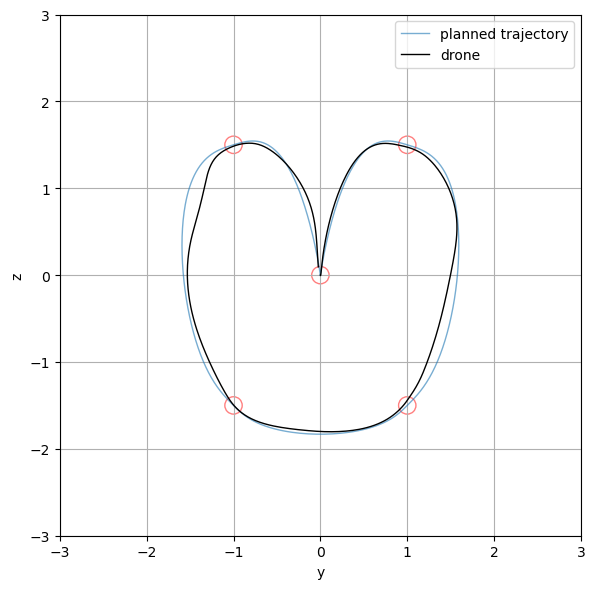

In [6]:
# Sample the full planned trajectory at uniform time, then overlay
# the drone's actual path. With the projection-based lookup, the drone
# should sit on the planned path; with the old time-based lookup it
# would be visibly inside the spirals.
ts_plan = np.linspace(0, traj.t_end, 600)
xy_plan = np.array([traj.setpoint(t)[:2] for t in ts_plan])

y = results[:Nidx + 1, 1]
z = results[:Nidx + 1, 2]

fig, ax = plt.subplots(1, figsize=(12, 6))
for _t in targets:
    ax.add_patch(plt.Circle((_t[0], _t[1]), _t[2], lw=1, color='red', alpha=0.5, fill=False))
ax.plot(xy_plan[:, 0], xy_plan[:, 1], color='C0', lw=1, alpha=0.6, label='planned trajectory')
ax.plot(y,             z,             color='k',  lw=1,           label='drone')
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid()
ax.legend()
plt.tight_layout()

## Inline replay


In [7]:
module.render_replay(drone, results[:Nidx + 1])

## Comparison

On the same five-target track:

* Notebook 4b (velocity cascade with step setpoints): about 17 seconds. Decoupled y and z, dimensionless tilt clip.
* Notebook 5 (model-based, step setpoints): about 10 seconds. Inversion gives the right tilt for the requested acceleration, but the drone still overshoots at every waypoint because the setpoint jumps.
* This notebook (model-based + fly-through trajectory + projection lookup + tangent lookahead): about 8 to 9 seconds. The drone never comes to rest before the last waypoint, the path is a smooth curve from start to finish, and it now tracks the planned trajectory within roughly $0.05$ m even though the trajectory is run aggressively (`a_plan = 6` m/s$^2$, close to the drone's wedge limit).

Two design choices are worth pointing out:

1. *Feedforward for the known part of the motion.* The trajectory's $\ddot{y}_0(t), \ddot{z}_0(t)$ supplies most of the commanded acceleration; the PID is only correcting tracking error, not generating motion. This is the *feedforward for known motion, feedback for unknown disturbances* split that turns up everywhere in instrument control, including the long control loops at gravitational-wave detectors.
2. *Setpoint by tangent step, not by clock advance.* The position setpoint is the projection of the drone onto the trajectory, plus a small step along the tangent. The tangent step does not bend, so the setpoint never sits on the inside of a corner and the PID never has a reason to cut one. Higher gain pulls the drone tighter onto the planned path, and the trajectory's `a_plan` can be pushed close to the drone's physical acceleration limit without the path collapsing inwards.

Two natural follow-ups, not implemented here:

1. Per-corner velocity scaling: tighter corners get a slower pass, straighter sections more speed.
2. Online replanning: replan the trajectory from the drone's actual position when tracking error exceeds a threshold. The current trajectory is open-loop; closing the planning loop would handle wind disturbances and modelling errors more gracefully.